Перші 5 рядків таблиці:
                    Month  America Tropical Interpretive Center  Avila Adobe  \
0  01/01/2014 12:00:00 AM                                  6602        24778   
1  02/01/2014 12:00:00 AM                                  5029        18976   
2  03/01/2014 12:00:00 AM                                  8129        25231   
3  04/01/2014 12:00:00 AM                                  2824        26989   
4  05/01/2014 12:00:00 AM                                 10694        36883   

   Chinese American Museum  Gateway to Nature Center  Firehouse Museum  \
0                     1581                       NaN              4486   
1                     1785                       NaN              4172   
2                     3229                       NaN              7082   
3                     2129                       NaN              6756   
4                     3676                       NaN             10858   

   Hellman Quon  IAMLA  Pico House   Visitor Cente

/tmp/ipykernel_4423/2774523144.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Month'] = pd.to_datetime(df['Month'])


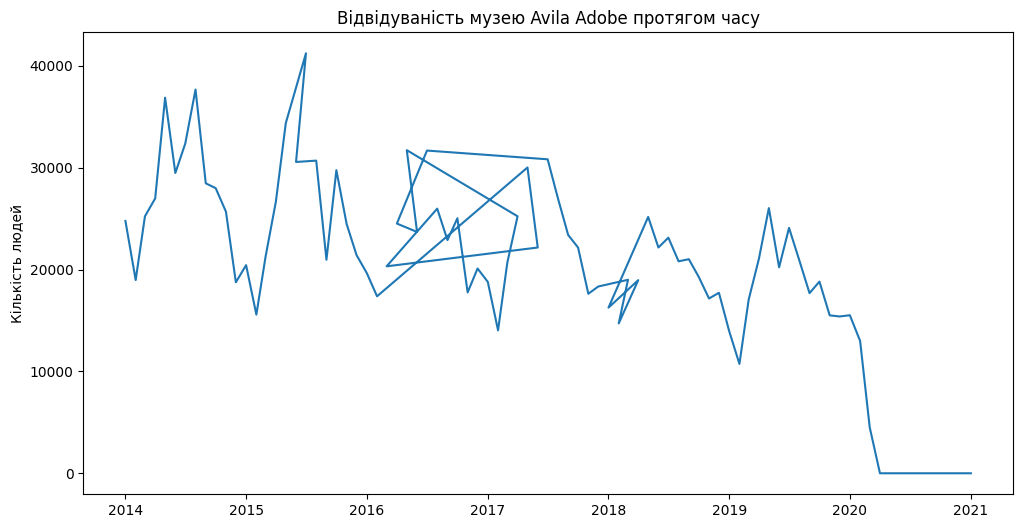

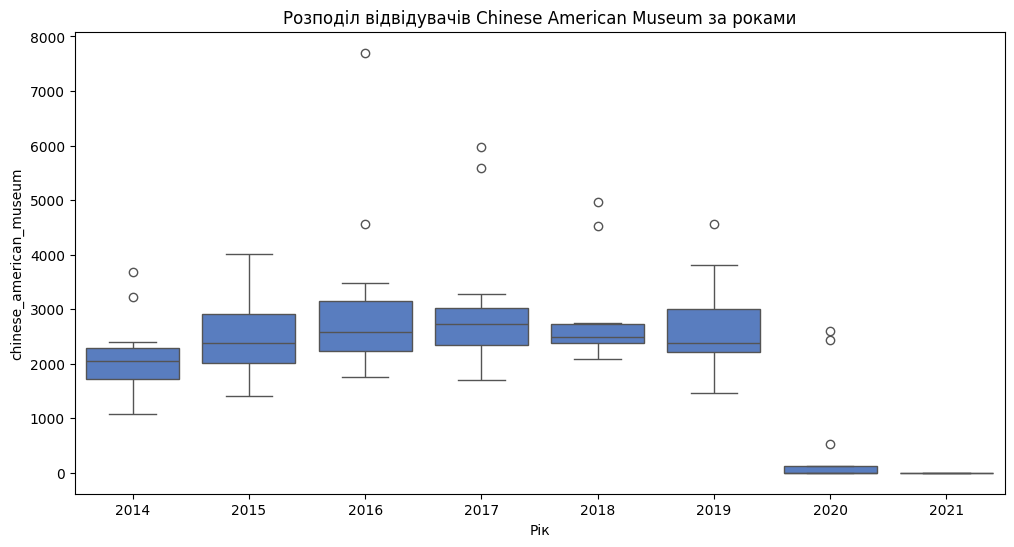

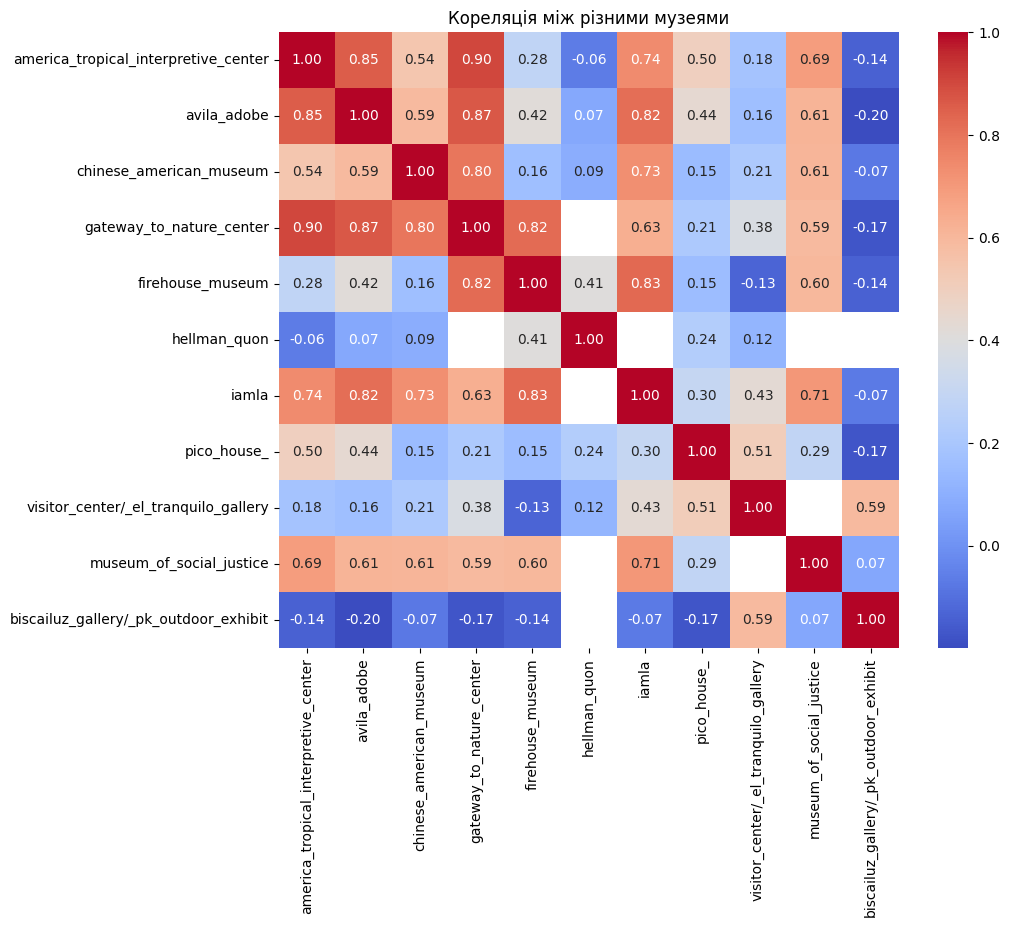

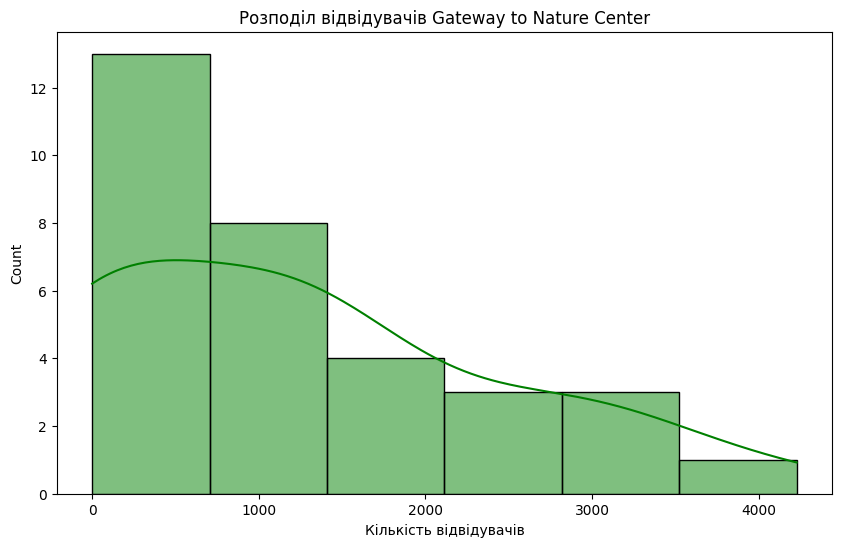

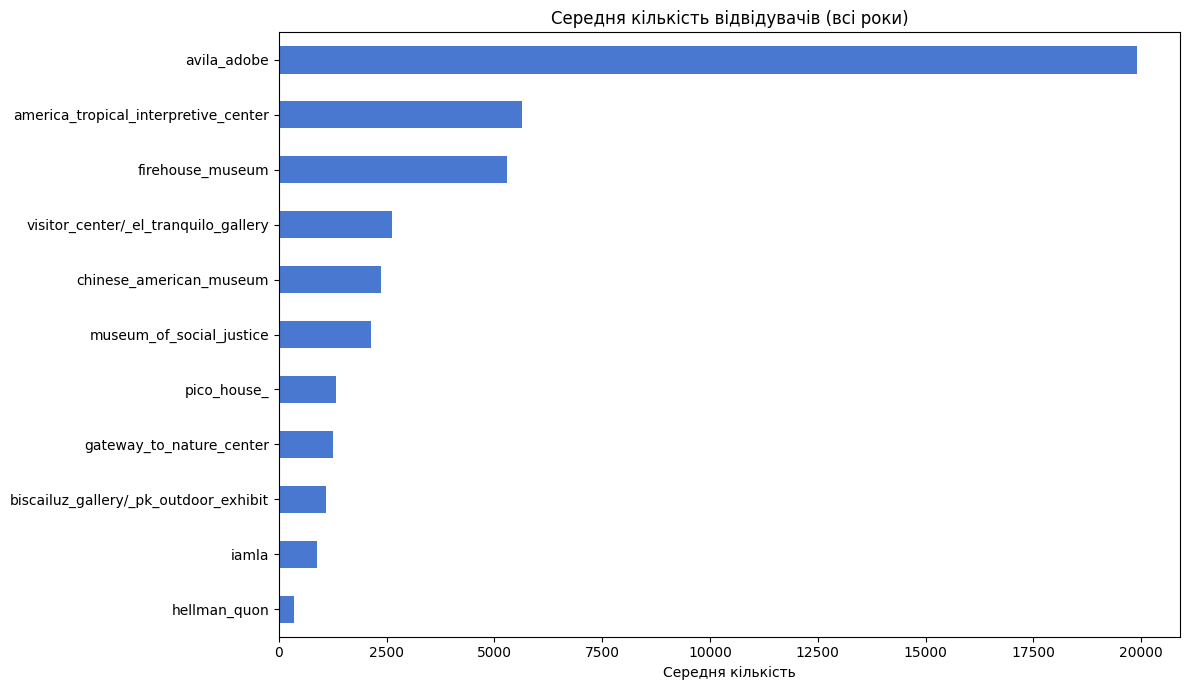

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Museum_Visitors.csv')

print("Перші 5 рядків таблиці:")
print(df.head())

print("\nСтатистика по датасету:")
print(f"Розмір: {df.shape}")
print("\nТипи даних:")
print(df.dtypes)
print("\nПропущені значення:")
print(df.isnull().sum())

if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f"\nДублікати видалено. Новий розмір: {df.shape}")

df['Month'] = pd.to_datetime(df['Month'])

years_list = df['Month'].dt.year.unique()
print(f"\nДані охоплюють наступні роки: {sorted(years_list)}")

rename_map = {
    'Month': 'date',
    'America Tropical Interpretive Center': 'america_tropical_interpretive_center',
    'Avila Adobe': 'avila_adobe',
    'Chinese American Museum': 'chinese_american_museum',
    'Firehouse Museum': 'firehouse_museum',
    'Gateway to Nature Center': 'gateway_to_nature_center'
}

df.columns = [rename_map.get(col, col.lower().replace(' ', '_')) for col in df.columns]
print("\nОновлені назви стовпців:")
print(df.columns.tolist())

museum_columns = [c for c in df.columns if c != 'date']
averages = df[museum_columns].mean()
print("\nСередня кількість відвідувачів:")
print(averages)

df_2018 = df[df['date'].dt.year == 2018]
print("\nМінімум за 2018 рік:")
print(df_2018[museum_columns].min())
print("\nМаксимум за 2018 рік:")
print(df_2018[museum_columns].max())

df_2015 = df[df['date'].dt.year == 2015].copy()
df_2015['total'] = df_2015[museum_columns].sum(axis=1)

top_month = df_2015.loc[df_2015['total'].idxmax(), 'date'].month_name()
low_month = df_2015.loc[df_2015['total'].idxmin(), 'date'].month_name()
print(f"\nУ 2015 році найбільше відвідувачів було у місяці: {top_month}")
print(f"Найменше відвідувачів було у місяці: {low_month}")

summer_18 = df_2018[df_2018['date'].dt.month.isin([6, 7, 8])]['avila_adobe'].sum()
winter_18 = df_2018[df_2018['date'].dt.month.isin([12, 1, 2])]['avila_adobe'].sum()
print(f"\nПосещаемость Avila Adobe у 2018 році: Літо = {summer_18}, Зима = {winter_18}")

df_2016 = df[df['date'].dt.year == 2016].copy()
df_2016['m_num'] = df_2016['date'].dt.month
correlation_2016 = df_2016[museum_columns + ['m_num']].corr()['m_num'].drop('m_num')
print("\nКореляція між місяцями та відвідуваністю (2016 рік):")
print(correlation_2016)

sns.set_palette("muted")

plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['avila_adobe'], color='tab:blue')
plt.title('Відвідуваність музею Avila Adobe протягом часу')
plt.ylabel('Кількість людей')
plt.show()

df['year_tag'] = df['date'].dt.year
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='year_tag', y='chinese_american_museum')
plt.title('Розподіл відвідувачів Chinese American Museum за роками')
plt.xlabel('Рік')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df[museum_columns].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Кореляція між різними музеями')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['gateway_to_nature_center'].dropna(), kde=True, color='green')
plt.title('Розподіл відвідувачів Gateway to Nature Center')
plt.xlabel('Кількість відвідувачів')
plt.show()

plt.figure(figsize=(12, 7))
averages.sort_values().plot(kind='barh')
plt.title('Середня кількість відвідувачів (всі роки)')
plt.xlabel('Середня кількість')
plt.tight_layout()
plt.show()